# Part 4 Task: Replicating Graphs

**Author:** Kelly Chen\
**Date:** 9/21/26

**Table of Contents**
1. [Plan for getting data](#sec1)
2. [Get data](#sec2)
3. [Make Graph 1](#sec3)
4. [Make Graph 2](#sec4)

<a id="sec1"></a>

## 1. Plan for getting data

The two graphics appear to be based on Wikipedia pageviews of KDramas released in 2023, in which Graph 1 ranks the top 19 most popular dramas with their pageviews, displayed as a horizontal bar chart with detailed labels. Graph 2 also shows the same dramas but displays a trend of the pageviews, centered around the peak pageview date for each drama. 

In order to get the pageviews from Wikipedia, I need to use mwclient to connect to each drama's wiki site to check if the wiki site exists, and then use mwviews to get the article views within the dates 2022-06-01 to 2024-06-01. I will use the given kdramas_2023.csv file and get the top 20 dramas based on popularity rank (excluding Bloodhound) to get the pageviews from. I noticed later that the titles of the dramas in the csv file vs. on Wikipedia are different; thus, I need to make sure that they match so that the page will exist when I try to find it.

<a id="sec2"></a>

## 2. Get data

In [34]:
import mwclient
from mwviews.api import PageviewsClient
import pandas as pd
import time
import re

In [5]:
kdramas = pd.read_csv("kdramas_2023.csv") #read given data
kdramas.head()

,Unnamed: 0,Year,Title_English,Episodes,Popularity,Aired,Aired On,Duration,Genres,Tags,Summary,Title_Korean,Also Known As,Content Rating,Score_Votes,Score,Ranked,Watchers
0,0,2023,High Cookie (2023),20,1638,"Oct 23, 2023 - Nov 23, 2023",NaN,34 min.,"['Thriller', 'Mystery', 'Youth', 'Fantasy']","['Bully Supporting Character', 'Student Suppor...",A teen fantasy thriller drama that tells the s...,하이쿠키,"Hai Kuki , Haikuki , Hi Cookie , Привет, печен...",18+ Restricted (violence & profanity),2440,7.3,8082,15709
1,1,2023,Strangers Again (2023),12,1515,"Jan 18, 2023 - Feb 23, 2023","Wednesday, Thursday",1 hr. 10 min.,"['Law', 'Romance', 'Drama']","[""Bickering Mains' Relationship"", 'Ex-spouse R...","Divorce lawyer Oh Ha Ra, known as the “goddess...",남이 될 수 있을까?,"Can I Be Someone Else , Can I Be Someone Else?...",15+ - Teens 15 or older,5187,7.2,9766,17025
2,2,2023,Hello! This Is Starbucks (2023),19,99999,"Jun 20, 2023 - Jul 27, 2023","Tuesday, Wednesday, Thursday",1 min.,['Life'],"['Café Setting', 'Short Length Series', 'Web S...",This web drama deals with a theme based on the...,안녕하세요! 스타벅스입니다,Annyeonghaseyo! Seutabeokseuibnida,Not Yet Rated,5,5.9,99999,105
3,3,2023,Adult Kids (2023),8,9473,"Jun 19, 2023 - Aug 7, 2023",Monday,10 min.,"['Life', 'Drama']","['Female Centered Plot', 'Short Length Series'...",A hyper-realistic drama depicting the daily li...,어른애들,"Crianças Adultas , Eoreunaedeul , The Adult Li...",Not Yet Rated,181,7.1,10086,1250
4,4,2023,My Demon (2023),16,40,"Nov 24, 2023 - Jan 20, 2024","Friday, Saturday",1 hr. 6 min.,"['Action', 'Comedy', 'Romance', 'Fantasy']","['Demon Male Lead', 'Supernatural', 'Heiress F...",Do Do Hee is the successor of the Future Group...,마이데몬,"Demonul Șarmant , Maidemon , Meu Demônio Favor...",15+ - Teens 15 or older,97628,8.3,1177,165957


In [14]:
# rename the title by removing year
kdramas["Title"] = (
    kdramas["Title_English"]
    .str.replace(r"\s*\(\d{4}\)$", "", regex=True) #use regex to identify year
    .str.strip()
)

print(kdramas[["Title", "Title_English"]].head()) #check if year is gone

                      Title                    Title_English
0               High Cookie               High Cookie (2023)
1           Strangers Again           Strangers Again (2023)
2  Hello! This Is Starbucks  Hello! This Is Starbucks (2023)
3                Adult Kids                Adult Kids (2023)
4                  My Demon                  My Demon (2023)


Get the top 20 most popular dramas, excluding Bloodhounds:

In [87]:
top20 = (
    kdramas[kdramas["Title"] != "Bloodhounds"]
    .sort_values("Popularity")
    .head(20)
)
top20_names = top20["Title"].tolist()
print(top20_names)

['Twinkling Watermelon', 'My Demon', 'King the Land', 'The Glory Part 2', 'Moving', "Death's Game", 'Welcome to Samdal-ri', 'See You in My 19th Life', 'Destined with You', 'The Good Bad Mother', 'My Lovely Liar', 'Crash Course in Romance', 'Love to Hate You', 'Perfect Marriage Revenge', 'A Time Called You', 'Doona!', 'Celebrity', 'Daily Dose of Sunshine', 'Gyeongseong Creature', 'Strong Girl Nam Soon']


In [100]:
#account for different wiki titles
wiki_names = {
    "The Glory Part 2": "The Glory (TV series)",
    "Moving": "Moving (South Korean TV series)",
    'Celebrity': "Celebrity (South Korean TV series)",
    "Love to Hate You": "Love to Hate You (TV series)",
    "Doona!": "Doona!",
    "Strong Girl Nam Soon": "Strong Girl Nam-soon"
        
}
drama_names = [
    wiki_names.get(title, title)
    for title in top20_names
]

print(drama_names)

['Twinkling Watermelon', 'My Demon', 'King the Land', 'The Glory (TV series)', 'Moving (South Korean TV series)', "Death's Game", 'Welcome to Samdal-ri', 'See You in My 19th Life', 'Destined with You', 'The Good Bad Mother', 'My Lovely Liar', 'Crash Course in Romance', 'Love to Hate You (TV series)', 'Perfect Marriage Revenge', 'A Time Called You', 'Doona!', 'Celebrity (South Korean TV series)', 'Daily Dose of Sunshine', 'Gyeongseong Creature', 'Strong Girl Nam-soon']


In [101]:
# connect to wikipedia
site = mwclient.Site("en.wikipedia.org")
p = PageviewsClient(user_agent="CS315 Student (kc126@wellesley.edu)")

In [98]:
start = "2022060100"
end = "2024060100"

Check if wikipedia page exists for the drama:

In [102]:
# check if wiki page exists for every drama
for drama in drama_names:
    page = site.pages[drama]
    print(page)
    if not page.exists:
        print(f"No existing Wikipedia page: {drama}")

<Page object 'Twinkling Watermelon' for <Site object 'en.wikipedia.org/w/'>>
<Page object 'My Demon' for <Site object 'en.wikipedia.org/w/'>>
<Page object 'King the Land' for <Site object 'en.wikipedia.org/w/'>>
<Page object 'The Glory (TV series)' for <Site object 'en.wikipedia.org/w/'>>
<Page object 'Moving (South Korean TV series)' for <Site object 'en.wikipedia.org/w/'>>
<Page object 'Death's Game' for <Site object 'en.wikipedia.org/w/'>>
<Page object 'Welcome to Samdal-ri' for <Site object 'en.wikipedia.org/w/'>>
<Page object 'See You in My 19th Life' for <Site object 'en.wikipedia.org/w/'>>
<Page object 'Destined with You' for <Site object 'en.wikipedia.org/w/'>>
<Page object 'The Good Bad Mother' for <Site object 'en.wikipedia.org/w/'>>
<Page object 'My Lovely Liar' for <Site object 'en.wikipedia.org/w/'>>
<Page object 'Crash Course in Romance' for <Site object 'en.wikipedia.org/w/'>>
<Page object 'Love to Hate You (TV series)' for <Site object 'en.wikipedia.org/w/'>>
<Page obje

In [104]:
# try get pageviews with mwviews
views = p.article_views('en.wikipedia', drama_names,
                        start='20220601', end='20240601')

list(views.items())[:5]

[(datetime.datetime(2022, 6, 1, 0, 0),
  {'Twinkling_Watermelon': None,
   'My_Demon': None,
   'King_the_Land': None,
   'The_Glory_(TV_series)': None,
   'Moving_(South_Korean_TV_series)': 199,
   "Death's_Game": None,
   'Welcome_to_Samdal-ri': None,
   'See_You_in_My_19th_Life': None,
   'Destined_with_You': None,
   'The_Good_Bad_Mother': None,
   'My_Lovely_Liar': None,
   'Crash_Course_in_Romance': None,
   'Love_to_Hate_You_(TV_series)': None,
   'Perfect_Marriage_Revenge': None,
   'A_Time_Called_You': 134,
   'Doona!': None,
   'Celebrity_(South_Korean_TV_series)': None,
   'Daily_Dose_of_Sunshine': None,
   'Gyeongseong_Creature': None,
   'Strong_Girl_Nam-soon': None}),
 (datetime.datetime(2022, 6, 2, 0, 0),
  {'Twinkling_Watermelon': None,
   'My_Demon': None,
   'King_the_Land': None,
   'The_Glory_(TV_series)': None,
   'Moving_(South_Korean_TV_series)': 176,
   "Death's_Game": None,
   'Welcome_to_Samdal-ri': None,
   'See_You_in_My_19th_Life': None,
   'Destined_with_Y

In [193]:
result = []

for date, dramas in views.items():
    for title, pgviews in dramas.items():
        result.append({
            "title": title.replace("_", " "),
            "date": date,
            "pageviews": pgviews
        })

pageviews = pd.DataFrame(result) #store result as df

pageviews.head()

,title,date,pageviews
0,Twinkling Watermelon,2022-06-01,NaN
1,My Demon,2022-06-01,NaN
2,King the Land,2022-06-01,NaN
3,The Glory (TV series),2022-06-01,NaN
4,Moving (South Korean TV series),2022-06-01,199.0


Reorder by pageviews (descending):

In [200]:
# get total pageviews for top popular drama
top_dramas_views = (
    pageviews.groupby("title")["pageviews"]
    .sum()
    .sort_values(ascending=False)
)

top_dramas_views

title
The Glory (TV series)                 5437126.0
Moving (South Korean TV series)       2891114.0
My Demon                              2822146.0
King the Land                         2697595.0
Gyeongseong Creature                  2081110.0
Twinkling Watermelon                  2061432.0
Death's Game                          1963050.0
Strong Girl Nam-soon                  1769430.0
Crash Course in Romance               1488160.0
Welcome to Samdal-ri                  1460872.0
Celebrity (South Korean TV series)    1441608.0
A Time Called You                     1349860.0
Perfect Marriage Revenge              1266164.0
See You in My 19th Life               1247697.0
The Good Bad Mother                   1172570.0
My Lovely Liar                        1169482.0
Doona!                                1033094.0
Love to Hate You (TV series)           822729.0
Daily Dose of Sunshine                 559765.0
Destined with You                        1156.0
Name: pageviews, dtype: float64

<a id="sec3"></a>

## 3. Make Graph 1

In [176]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

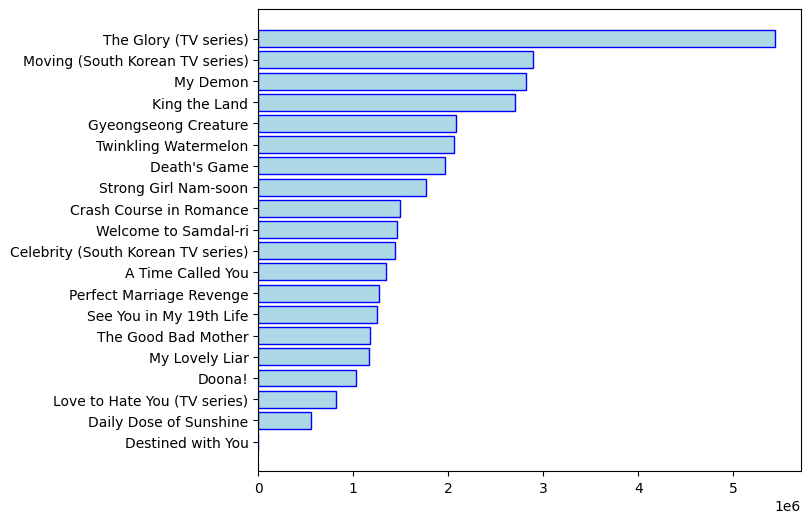

In [182]:
# total pageviews per drama
plot_data = top_dramas_views.sort_values(ascending=True) #most viewed at top

fig, ax = plt.subplots(figsize=(7, 6))

bars = ax.barh(
    plot_data.index,
    plot_data.values,
    color="lightblue",
    edgecolor="blue",
    linewidth=1
)

In [183]:
# pageview totals at the end of each bar
for bar, value in zip(bars, plot_data.values):
    ax.text(
        value + 30_000,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f}",
        va="center",
        fontsize=9
    )

# labels
ax.set_xlabel("Total Pageviews")
ax.set_title("Pageviews per Show (2022-06-01 to 2024-06-01)")

Text(0.5, 1.0, 'Pageviews per Show (2022-06-01 to 2024-06-01)')

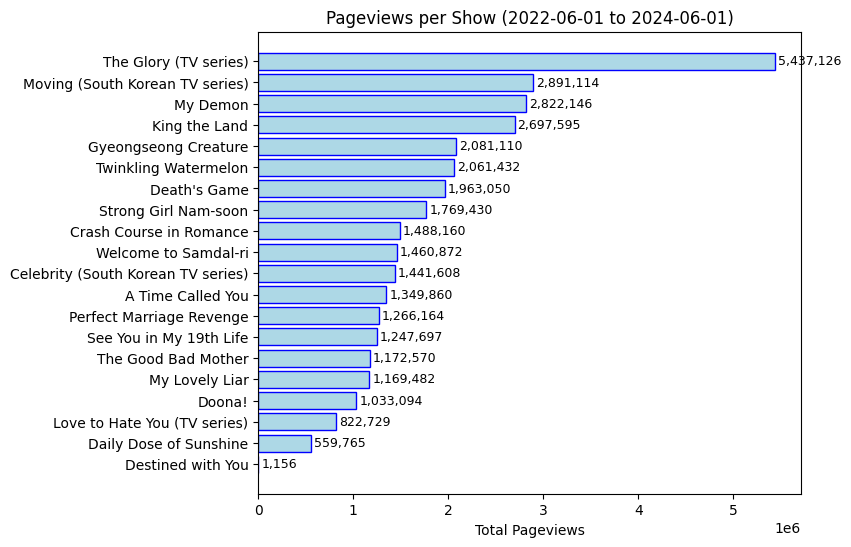

In [184]:
fig

<a id="sec4"></a>

## 4. Make Graph 2

In [237]:
pageviews["date"] = pd.to_datetime(pageviews["date"])

In [238]:
plot_data = pageviews.copy()

# find peak
peak = plot_data.groupby("title")["pageviews"].idxmax() #max
peaks = plot_data.loc[peak, ["title", "date"]] 

In [239]:
# find the peak for each drama in each row
plot_data = plot_data.merge(
    peaks.rename(columns={"date": "peak_date"}),
    on="title",
    how="left"
)

In [240]:
plot_data["days_relative"] = (
    plot_data["date"] - plot_data["peak_date"]
).dt.days

plot_data = plot_data[
    plot_data["days_relative"].between(-100, 100) # days around peak
]

In [241]:
drama_order = drama_names
plot_data["title"] = pd.Categorical(
    plot_data["title"],
    categories=drama_order,
    ordered=True
)

In [242]:
colors = [
    "lightblue",
    "orange",
    "green",
    "red",
    "purple",
    "brown",
    "pink",
    "gray",
    "yellow",
    "teal",
    "red",
    "gray",
    "blue",
    "green",
    "purple",
    "orange",
    "yellow",
    "brown",
    "pink",
    "lightgray"
]

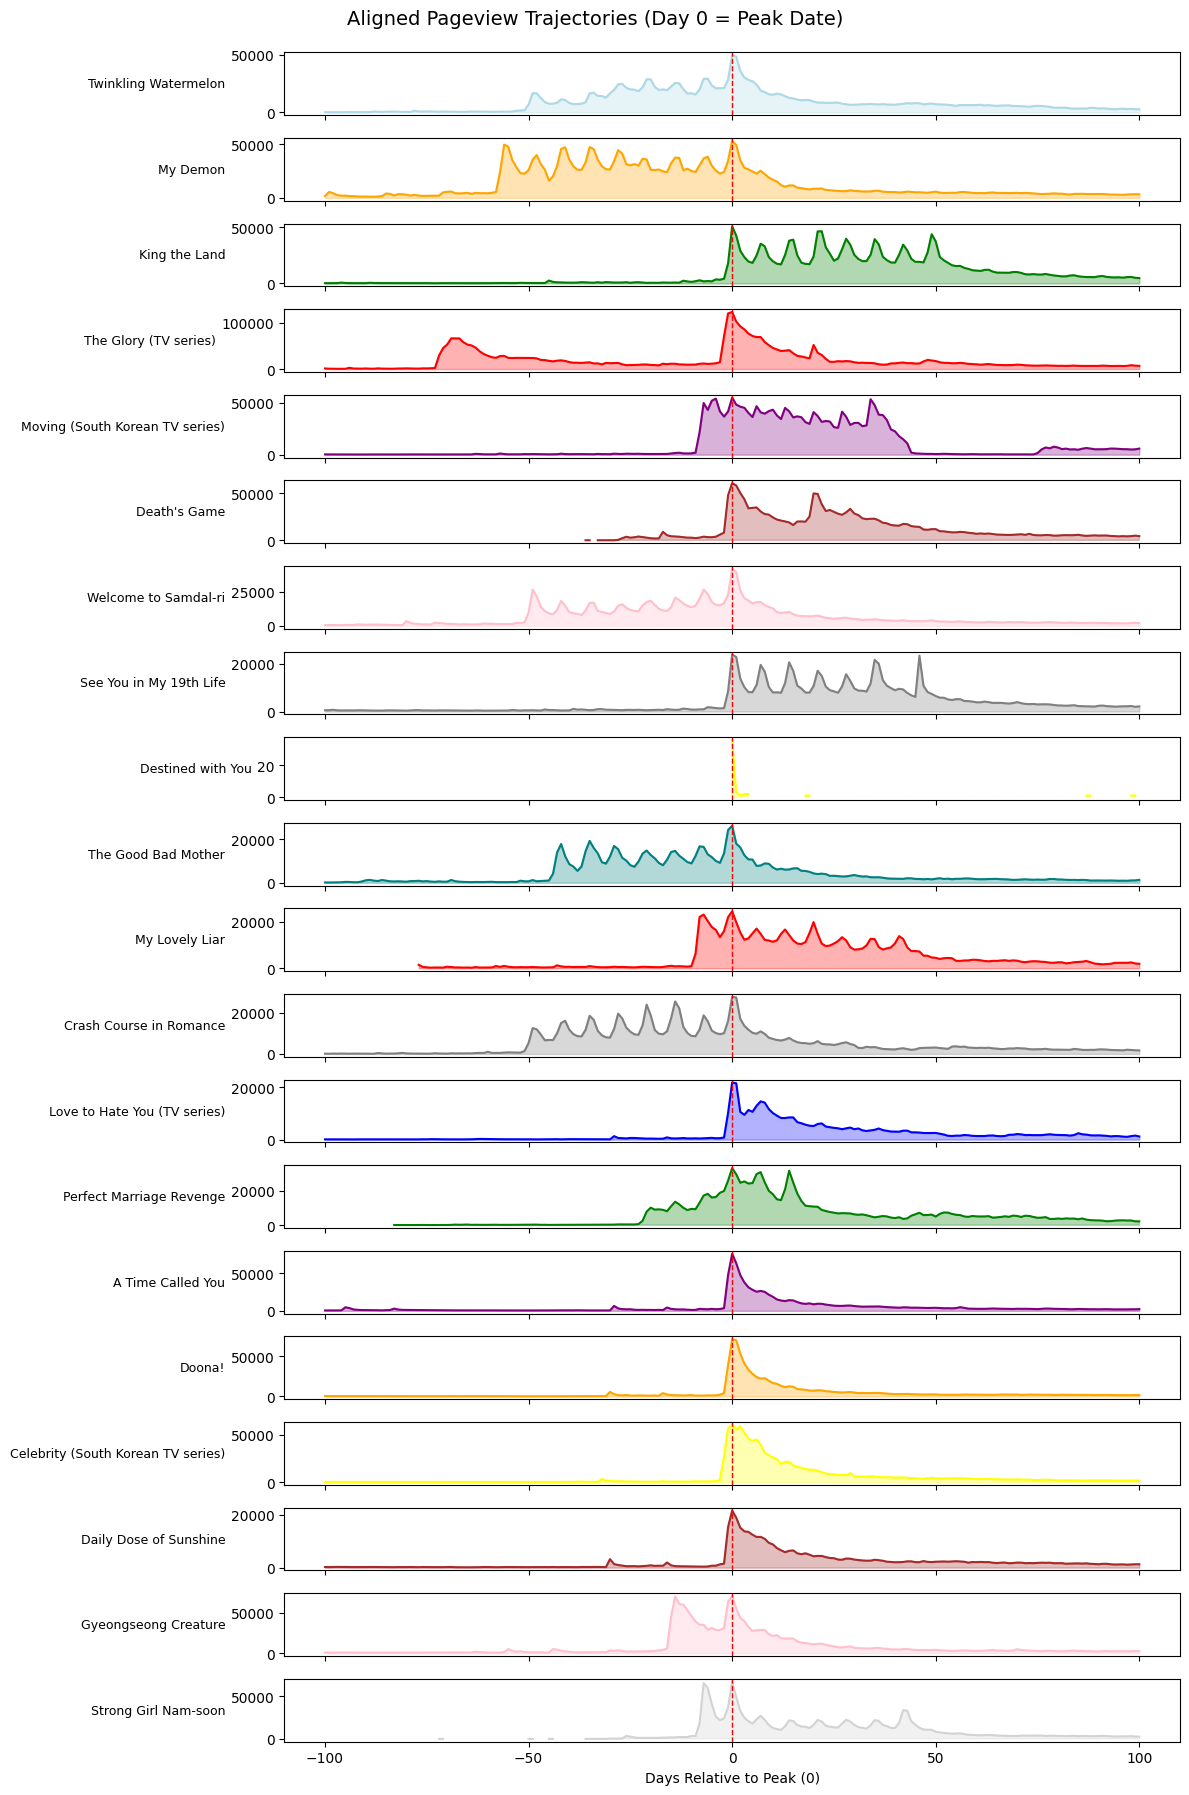

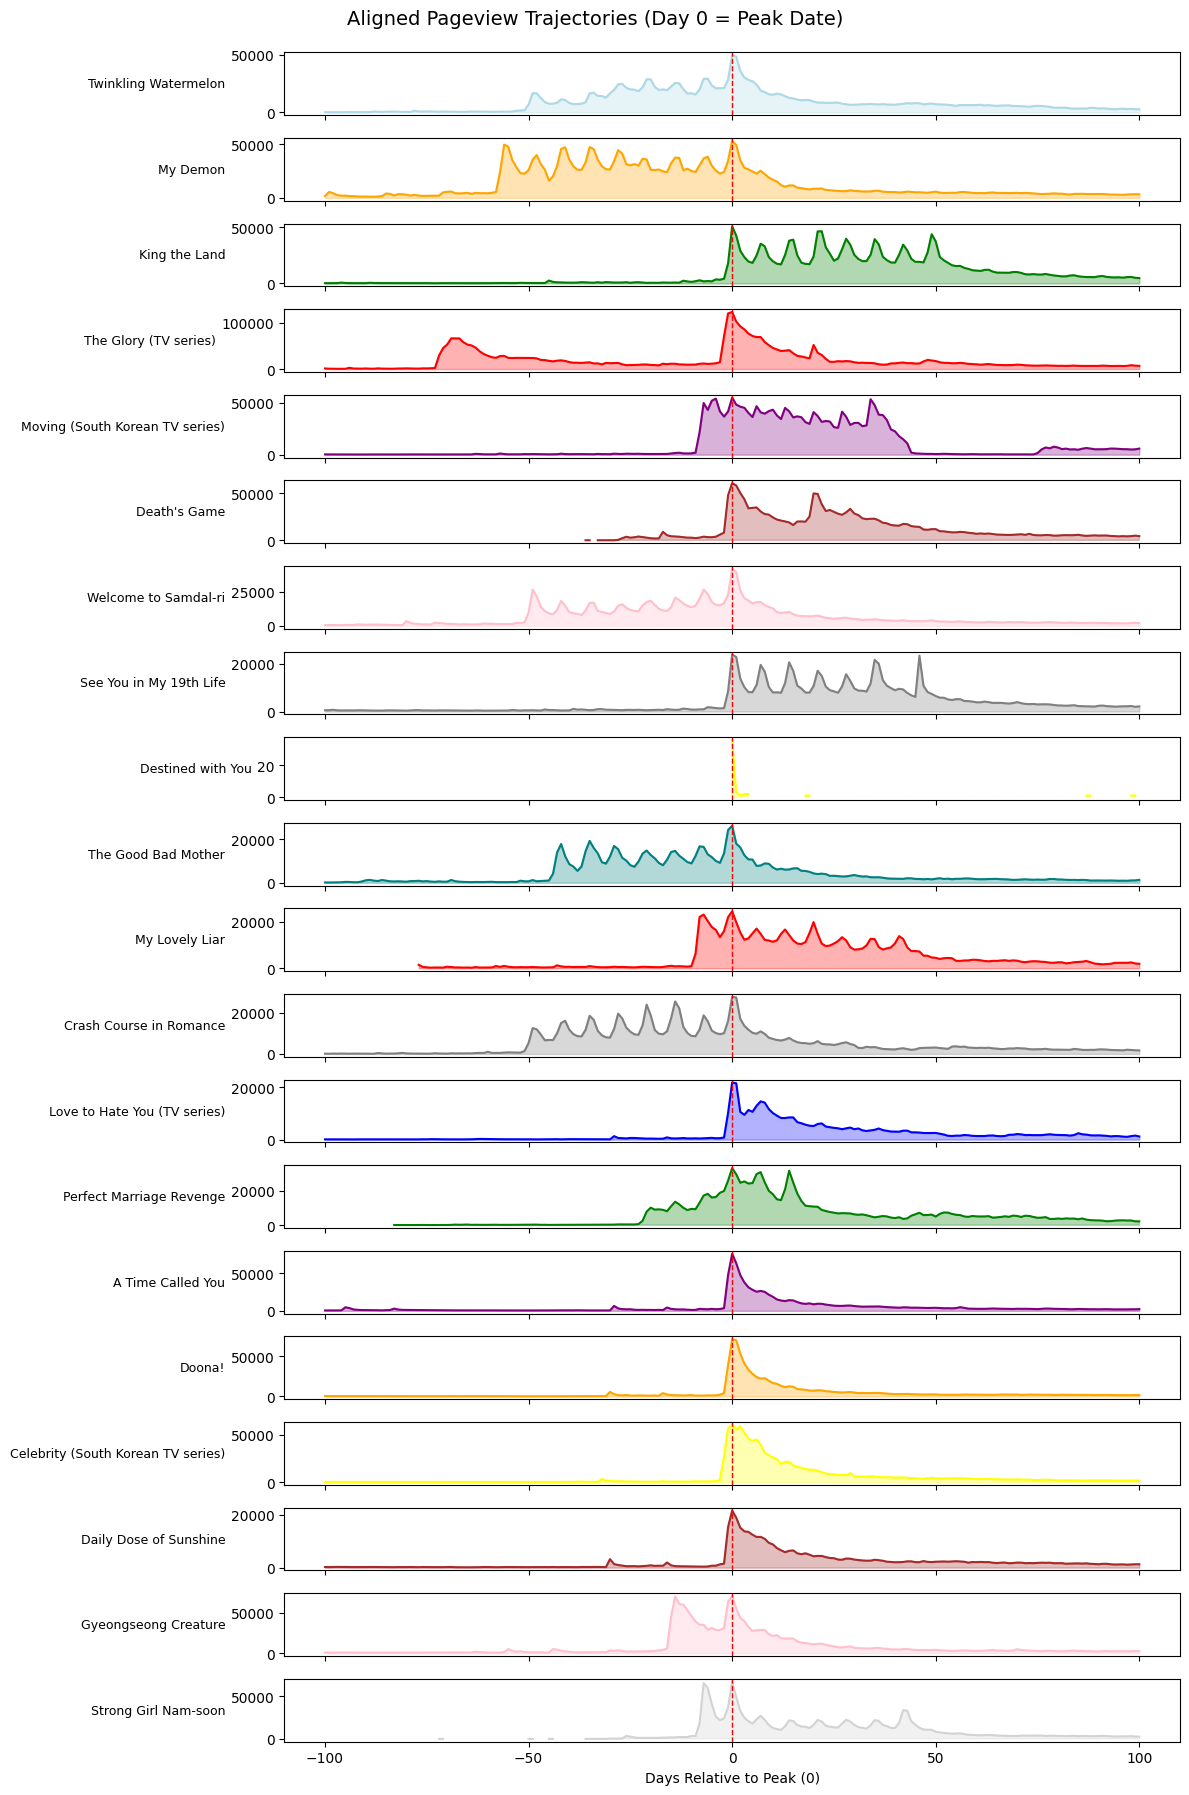

In [243]:
fig, axes = plt.subplots(
    nrows=len(drama_order),
    ncols=1,
    figsize=(12, 18),
    sharex=True #share x axis
)

for i, drama in enumerate(drama_order):
    drama_data = plot_data[
        plot_data["title"] == drama
    ].sort_values("days_relative")

    axes[i].plot(
        drama_data["days_relative"],
        drama_data["pageviews"],
        color=colors[i],
        linewidth=1.5
    )

    # shade area
    axes[i].fill_between(
        drama_data["days_relative"],
        drama_data["pageviews"],
        alpha=0.3,
        color=colors[i]
    )

    # red dashed line
    axes[i].axvline(
        0,
        color="red",
        linestyle="--",
        linewidth=1
    )

    # label drama title
    axes[i].set_ylabel(
        drama.replace("_", " "),
        rotation=0,
        ha="right",
        va="center",
        fontsize=9
    )


axes[-1].set_xlabel("Days Relative to Peak (0)")
axes[-1].set_xticks([-100, -50, 0, 50, 100])

fig.suptitle(
    "Aligned Pageview Trajectories (Day 0 = Peak Date)",
    fontsize=14,
    y=0.995
)

plt.tight_layout()
fig